# Telecom Customer Churn: Model Selection

Load and prepare the source data, compare classifiers, select a constrained decision threshold, and export the chosen model. This notebook runs independently of the EDA notebook.


In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = next(
    parent for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv").is_file()
)
file_path = project_root / "data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

sns.set_theme(style="whitegrid")
churn_palette = {"No": "#4C78A8", "Yes": "#E45756"}

df = df.drop(columns="customerID")
df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "Yes", 0: "No"})
text_columns = df.select_dtypes(include="str").columns
df[text_columns] = df[text_columns].apply(lambda column: column.str.strip())
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
new_customer_missing_charge = (
    df["TotalCharges"].isna() & df["tenure"].eq(0) & df["Churn"].eq("No")
)
df.loc[new_customer_missing_charge, "TotalCharges"] = 0


In [18]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
    roc_curve
)
from sklearn.model_selection import (
    cross_val_predict,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

# This is the largest allowed fraction of retained customers that may be
# incorrectly sent to the churn-retention campaign.
MAX_FALSE_POSITIVE_RATE = 0.31

def positive_class_scores(estimator, X_values):
    # Most models return churn probabilities. SVC returns decision scores.
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_values)[:, 1]
    return estimator.decision_function(X_values)

def recall_at_fpr_cap(estimator, X_values, y_values):
    # Compare models by the highest recall they can reach without
    # exceeding the allowed false-positive rate.
    scores = positive_class_scores(estimator, X_values)
    false_positive_rates, recalls, _ = roc_curve(y_values, scores)
    allowed_recalls = recalls[
        false_positive_rates <= MAX_FALSE_POSITIVE_RATE
    ]
    return allowed_recalls.max() if len(allowed_recalls) else 0.0

## Baseline churn model

A logistic-regression pipeline provides an interpretable baseline for predicting churn. All preprocessing is fitted inside the pipeline so that transformations learned from the training data are applied consistently during cross-validation and final testing.

In [19]:
# Create the feature table
X = df.drop(columns=["Churn"])

# Create the target
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

### Feature and target definition

The target is encoded as `1` for churn and `0` for retention. Predictor columns are separated by data type so categorical and numerical features can receive the appropriate preprocessing.

In [20]:
# Get categorical features
categorical_features = (
    X
    .select_dtypes(include="str")
    .columns
    .tolist()
)


numeric_features = [
    column
    for column in X.columns
    if column not in categorical_features 
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['tenure', 'MonthlyCharges', 'TotalCharges']


### Train–test split

The data is split into an 80% training set and a 20% holdout test set. Stratification preserves the original churn rate in both partitions, while `random_state=42` makes the split reproducible. The test set remains untouched until the final evaluation.

In [21]:
# Keep 20% completely untouched for the final testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining churn distribution:")
print(
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTest churn distribution:")
print(
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Training rows: 5634
Test rows: 1409

Training churn distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Test churn distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


### Preprocessing

Categorical variables are one-hot encoded, with previously unseen categories ignored safely at prediction time. Numerical variables are rescaled to the 0–1 range so the logistic-regression regularization treats their coefficient magnitudes comparably.

In [22]:
preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "numeric",
        MinMaxScaler(),
        numeric_features
    )
])

### Modeling pipeline

The preprocessing steps and logistic-regression classifier are combined into one pipeline. This design reduces data-leakage risk because every cross-validation fold learns its encodings and scaling parameters from that fold's training portion only.

In [23]:
logistic_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            solver="liblinear",
            max_iter=1000,
            random_state=42
        )
    )
])

### Cross-validation strategy

Five-fold stratified cross-validation estimates performance across multiple train–validation partitions while preserving the churn proportion in each fold. Shuffling with a fixed random seed improves reproducibility.

In [24]:
# Splits training set for validation with shuffled combinations
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Hyperparameter search space

The search expands regularization below the previous boundary winner and tests class weights around the observed imbalance. Each candidate is judged by the highest churn recall it can achieve while keeping the validation false-positive rate at or below 31%.

In [25]:
logistic_parameter_grid = {
    # Smaller C means stronger regularization.
    "model__C": [
        0.001,
        0.003,
        0.01,
        0.03,
        0.1
    ],
    "model__l1_ratio": [
        0.0, 
        1.0
    ],
    # Class weights alter the fitted boundary; the later threshold step
    # separately controls which customers receive retention outreach.
    "model__class_weight": [
        None,
        "balanced",
        {0: 1, 1: 2.5},
        {0: 1, 1: 3.0},
        {0: 1, 1: 3.5},
        {0: 1, 1: 4.0}
    ]
}

### Model selection

Grid search evaluates every parameter combination using constrained recall. Within each validation fold, it measures the best recall available without allowing more than 31% of retained customers to become false positives. F2 is still reported later, but it no longer permits unlimited unnecessary outreach during model selection.

In [26]:
# Choose the parameters with the best recall under the FPR cap.
logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_parameter_grid,
    scoring=recall_at_fpr_cap,
    cv=cross_validation,
    n_jobs=-1,
    verbose=1
)

logistic_search.fit(
    X_train, 
    y_train
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.003, ...], 'model__class_weight': [None, 'balanced', ...], 'model__l1_ratio': [0.0, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function rec...0024F7FF91590>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple met

### Test performance

The best cross-validated pipeline is evaluated once on the untouched test set. Its F2-score is reported directly, while the classification report presents class-specific precision, recall, and F1-score alongside overall accuracy.

In [27]:
logistic_model = logistic_search.best_estimator_

logistic_predictions = logistic_model.predict(
    X_test
)

print("Best parameters:")
print(logistic_search.best_params_)

print("\nBest cross-validation recall at the FPR cap:")
print(round(logistic_search.best_score_, 3))

print("\nTest F2-score:")
print(round(fbeta_score(y_test, logistic_predictions, beta=2), 3))

print(classification_report(
    y_test, 
    logistic_predictions,
    target_names=["Stayed", "Churned"],
    digits=3
    ))

Best parameters:
{'model__C': 0.1, 'model__class_weight': {0: 1, 1: 2.5}, 'model__l1_ratio': 0.0}

Best cross-validation recall at the FPR cap:
0.834

Test F2-score:
0.692
              precision    recall  f1-score   support

      Stayed      0.894     0.744     0.812      1035
     Churned      0.516     0.757     0.614       374

    accuracy                          0.747      1409
   macro avg      0.705     0.750     0.713      1409
weighted avg      0.794     0.747     0.760      1409



### Confusion matrix

The confusion matrix translates the evaluation metrics into customer counts, showing how many churners were detected or missed and how many retained customers were incorrectly flagged.

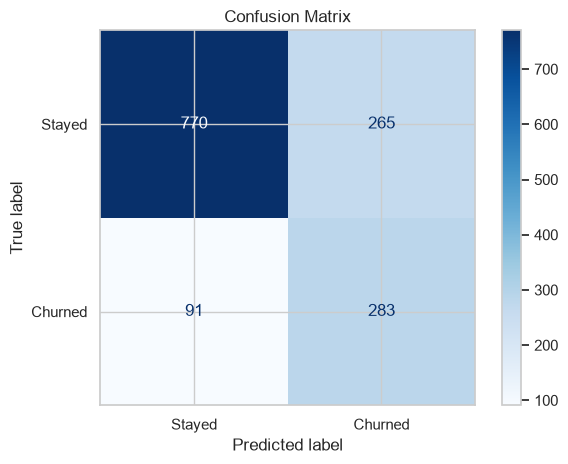

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    labels=[0, 1],
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Logistic-regression interpretation

The expanded search tests stronger regularization and class weights around the previous boundary winner. `best_score_` now represents validation recall under the 31% FPR cap rather than F2 at the default threshold. The later constrained-threshold table supplies the fair operational comparison.

Logistic regression remains useful as an interpretable baseline: its coefficients describe additive churn risk, while its threshold can be adjusted independently when campaign capacity changes.

---

## Decision-tree classifier

A decision tree is evaluated as a nonlinear alternative to logistic regression. It can learn threshold-based rules and interactions between customer attributes without requiring those relationships to be specified in advance. The same training split, cross-validation folds, preprocessing, and constrained-recall objective are retained for a fair comparison.

### Modeling pipeline

The decision tree is combined with the existing preprocessor in a single pipeline, preventing information from the validation folds from influencing preprocessing. One-hot encoding is still required for categorical variables; numerical scaling is not necessary for a tree, but retaining the shared preprocessor keeps the model comparison consistent. A fixed random seed makes the tree reproducible.

In [29]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

### Hyperparameter search space

The expanded search tunes the tree's split rules, pruning, and sensitivity to churners:

- `max_depth` limits the number of decision levels and reduces the risk of an overly complex tree.
- `min_samples_leaf` and `min_samples_split` require customer segments to contain enough observations to form stable rules.
- `ccp_alpha` removes weak branches through cost-complexity pruning.
- `criterion` compares Gini impurity with logarithmic loss.
- `class_weight` increases the cost of misclassifying churners, encouraging higher churn recall.

Randomized search keeps the larger search affordable. Every candidate must maximize recall under the same 31% validation false-positive-rate cap.

In [30]:
tree_parameter_distributions = {
    "model__criterion": [
        "gini",
        "log_loss"
    ],
    "model__max_depth": [
        4,
        5,
        6,
        7,
        8,
        10,
        None
    ],
    "model__min_samples_leaf": [
        10,
        15,
        20,
        30,
        40,
        60
    ],
    "model__min_samples_split": [
        30,
        50,
        75,
        100,
        150
    ],
    "model__ccp_alpha": [
        0.0,
        0.00001,
        0.00003,
        0.0001,
        0.0003,
        0.001,
        0.003,
        0.01
    ],
    "model__class_weight": [
        None,
        "balanced",
        {0: 1, 1: 2.5},
        {0: 1, 1: 3.0},
        {0: 1, 1: 3.5},
        {0: 1, 1: 4.0},
        {0: 1, 1: 4.5},
        {0: 1, 1: 5.0}
    ]
}

### Model selection

Randomized search evaluates 80 combinations using the same five-fold stratified cross-validation strategy. It selects the tree with the highest validation recall available under the 31% false-positive-rate cap. Training scores are retained to help diagnose overfitting.

In [31]:
tree_search = RandomizedSearchCV(
    estimator=tree_pipeline,
    param_distributions=tree_parameter_distributions,
    n_iter=80,
    scoring=recall_at_fpr_cap,
    cv=cross_validation,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

tree_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__ccp_alpha': [0.0, 1e-05, ...], 'model__class_weight': [None, 'balanced', ...], 'model__criterion': ['gini', 'log_loss'], 'model__max_depth': [4, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",<function rec...0024F7FF91590>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be co

### Test performance

The best cross-validated tree is evaluated on the untouched test set. Its F2-score, selected depth, and number of leaves are reported, while the classification report measures the trade-off between identifying churners and incorrectly flagging retained customers.

In [32]:
tree_model = tree_search.best_estimator_

tree_predictions = tree_model.predict(
    X_test
)

print("Best decision-tree parameters:")
print(tree_search.best_params_)

print("\nBest cross-validation recall at the FPR cap:")
print(round(tree_search.best_score_, 3))

print("\nTest F2-score:")
print(round(fbeta_score(y_test, tree_predictions, beta=2), 3))

selected_tree = tree_model.named_steps["model"]

print("Tree depth:", selected_tree.get_depth())
print("Number of leaves:", selected_tree.get_n_leaves())

print(
    classification_report(
        y_test,
        tree_predictions,
        target_names=[
            "Stayed",
            "Churned"
        ],
        digits=3
    )
)

Best decision-tree parameters:
{'model__min_samples_split': 100, 'model__min_samples_leaf': 40, 'model__max_depth': 8, 'model__criterion': 'gini', 'model__class_weight': {0: 1, 1: 2.5}, 'model__ccp_alpha': 0.0003}

Best cross-validation recall at the FPR cap:
0.817

Test F2-score:
0.698
Tree depth: 8
Number of leaves: 52
              precision    recall  f1-score   support

      Stayed      0.897     0.756     0.820      1035
     Churned      0.529     0.759     0.623       374

    accuracy                          0.757      1409
   macro avg      0.713     0.757     0.722      1409
weighted avg      0.799     0.757     0.768      1409



### Confusion matrix

The confusion matrix presents the decision tree's predictions as customer counts. This makes the operational cost of false negatives (missed churners) and false positives (unnecessary retention contacts) easier to assess.

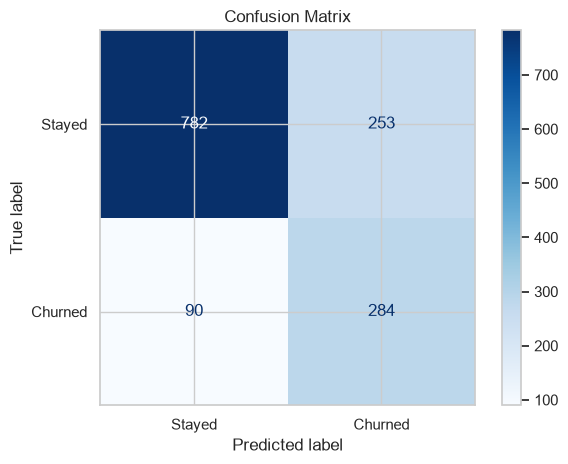

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_predictions,
    labels=[0, 1],
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Decision-tree interpretation and model comparison

The selected tree now comes from a broader randomized search that includes split-size controls and cost-complexity pruning. Its depth and number of leaves show how complicated the learned customer segments are. Compare its constrained recall and FPR with the other models before accepting a higher-variance tree based on one test score.

---

## Random-forest classifier

A random forest is evaluated to determine whether an ensemble of decision trees can improve churn detection. Each tree is trained on a sample and considers a random subset of features when splitting, which generally reduces the variance and overfitting risk of a single decision tree. The same data split, preprocessing, cross-validation folds, and constrained-recall objective are retained for comparability.

### Modeling pipeline

The random forest is placed inside the existing preprocessing pipeline so that categorical encoding is learned independently within each cross-validation fold. As with the decision tree, numerical scaling is not required by the model, but retaining the shared preprocessor ensures a consistent comparison.

In [34]:
from sklearn.ensemble import RandomForestClassifier

forest_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=400,
            bootstrap=True,
            random_state=42
        )
    )
])

### Hyperparameter search space

The expanded search tunes tree complexity, tree diversity, bootstrap sampling, and sensitivity to churners:

- `max_depth` limits the complexity of each tree and helps prevent overfitting.
- `min_samples_leaf` and `min_samples_split` smooth highly specific rules.
- `max_features` controls how many transformed features are available at each split.
- `max_samples` changes the bootstrap sample size and therefore the diversity between trees.
- `class_weight` increases the cost of missing churners. `balanced_subsample` recalculates automatic class weights separately for each bootstrap sample.

The forest uses 400 trees for stable comparisons while randomized search evaluates 80 structural combinations. The selected candidate must maximize recall without exceeding the 31% validation false-positive-rate cap.

In [35]:
forest_parameter_distributions = {
    "model__criterion": [
        "gini",
        "log_loss"
    ],
    "model__max_depth": [
        4,
        5,
        6,
        8,
        None
    ],
    "model__min_samples_leaf": [
        5,
        10,
        15,
        20,
        30
    ],
    "model__min_samples_split": [
        2,
        10,
        20,
        40
    ],
    "model__max_features": [
        "sqrt",
        "log2",
        0.3,
        0.5,
        0.7
    ],
    "model__max_samples": [
        0.65,
        0.8,
        None
    ],
    "model__class_weight": [
        None,
        "balanced",
        "balanced_subsample",
        {0: 1, 1: 2.5},
        {0: 1, 1: 3.0},
        {0: 1, 1: 3.5},
        {0: 1, 1: 4.0},
        {0: 1, 1: 4.5}
    ]
}

### Model selection

Randomized search evaluates 80 combinations with five-fold stratified cross-validation. It compares forests by recall under the common 31% false-positive-rate cap instead of rewarding a model for sending substantially more customers to retention.

In [36]:
forest_search = RandomizedSearchCV(
    estimator=forest_pipeline,
    param_distributions=forest_parameter_distributions,
    n_iter=80,
    scoring=recall_at_fpr_cap,
    cv=cross_validation,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

forest_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': [None, 'balanced', ...], 'model__criterion': ['gini', 'log_loss'], 'model__max_depth': [4, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",<function rec...0024F7FF91590>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations othe

### Test performance

The best cross-validated forest is evaluated on the untouched test set. Its F2-score is reported directly, and the classification report shows whether stronger churn recall is accompanied by acceptable precision and overall classification performance.

In [37]:
forest_model = forest_search.best_estimator_

forest_predictions = forest_model.predict(
    X_test
)

print("Best random-forest parameters:")
print(forest_search.best_params_)

print("\nBest cross-validation recall at the FPR cap:")
print(round(forest_search.best_score_, 3))

print("\nTest F2-score:")
print(round(fbeta_score(y_test, forest_predictions, beta=2), 3))

print(
    classification_report(
        y_test,
        forest_predictions,
        target_names=[
            "Stayed",
            "Churned"
        ],
        digits=3
    )
)

Best random-forest parameters:
{'model__min_samples_split': 20, 'model__min_samples_leaf': 5, 'model__max_samples': None, 'model__max_features': 'sqrt', 'model__max_depth': 8, 'model__criterion': 'gini', 'model__class_weight': {0: 1, 1: 4.0}}

Best cross-validation recall at the FPR cap:
0.849

Test F2-score:
0.73
              precision    recall  f1-score   support

      Stayed      0.921     0.666     0.773      1035
     Churned      0.477     0.842     0.609       374

    accuracy                          0.713      1409
   macro avg      0.699     0.754     0.691      1409
weighted avg      0.803     0.713     0.729      1409



### Confusion matrix

The confusion matrix expresses random-forest performance as customer counts, making the additional churners detected and retained customers incorrectly flagged directly comparable with the earlier models.

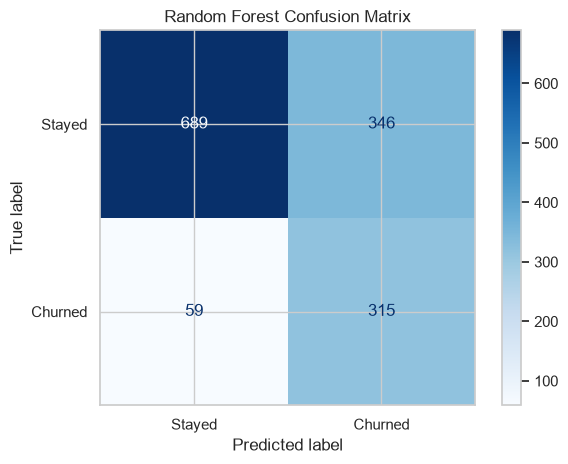

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_predictions,
    labels=[0, 1],
    display_labels=[
        "Stayed",
        "Churned"
    ],
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

### Random-forest interpretation and model comparison

The improved forest search holds the number of trees at 400 while tuning feature sampling, customer sampling, split sizes, depth, criterion, and class weights. This focuses the search on better customer ranking and tree diversity. Its final recall must be judged at the common FPR cap because the earlier higher recall was achieved by flagging substantially more retained customers.

## LightGBM classifier

LightGBM is evaluated as a gradient-boosting model. Unlike the random forest, which builds independent trees, LightGBM builds trees sequentially so that each new tree focuses on errors made by the previous trees. This can capture nonlinear relationships efficiently. The same data split, preprocessing, cross-validation folds, and constrained-recall objective are retained for a fair comparison.

### Modeling pipeline

LightGBM is placed inside the existing preprocessing pipeline. Categorical features are one-hot encoded within each cross-validation fold, while the numerical features use the same scaling as the earlier models. LightGBM does not require scaling, but reusing the preprocessor keeps the input data consistent across all models.

In [39]:
from lightgbm import LGBMClassifier

lightgbm_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        LGBMClassifier(
            objective="binary",
            random_state=42,
            n_jobs=1,
            verbosity=-1
        )
    )
])

### Hyperparameter search space

The earlier LightGBM search selected values at several grid boundaries: the most trees, the smallest learning rate, the fewest leaves, and the largest churn weight. The expanded search therefore explores farther in those directions and adds regularization controls:

- `n_estimators` and `learning_rate` jointly control how gradually the model learns.
- `num_leaves`, `max_depth`, and `min_child_samples` control tree complexity.
- `reg_alpha` and `reg_lambda` add L1 and L2 regularization.
- `colsample_bytree`, `subsample`, and `subsample_freq` introduce feature and customer sampling.
- `scale_pos_weight` increases the cost of missing churners in this binary-classification problem.

The complete combination set would be unnecessarily large, so randomized search tests 60 reproducible combinations.

In [40]:
lightgbm_parameter_distributions = {
    "model__n_estimators": [
        200,
        300,
        500,
        800
    ],
    "model__learning_rate": [
        0.01,
        0.02,
        0.03,
        0.05
    ],
    "model__num_leaves": [
        3,
        5,
        7,
        10,
        15
    ],
    "model__max_depth": [
        3,
        4,
        5,
        -1
    ],
    "model__min_child_samples": [
        10,
        20,
        40,
        60
    ],
    "model__reg_alpha": [
        0,
        0.1,
        0.5,
        1
    ],
    "model__reg_lambda": [
        0,
        0.1,
        0.5,
        1
    ],
    "model__colsample_bytree": [
        0.7,
        0.85,
        1.0
    ],
    "model__subsample": [
        0.7,
        0.85,
        1.0
    ],
    "model__subsample_freq": [
        1
    ],
    "model__scale_pos_weight": [
        1,
        2,
        2.5,
        3,
        3.5,
        4
    ]
}

### Model selection

Randomized search evaluates 60 LightGBM parameter combinations using the same five-fold stratified cross-validation. Candidates are compared by recall under the 31% validation false-positive-rate cap, and `random_state=42` makes the sampled combinations reproducible.

In [41]:
lightgbm_search = RandomizedSearchCV(
    estimator=lightgbm_pipeline,
    param_distributions=lightgbm_parameter_distributions,
    n_iter=60,
    scoring=recall_at_fpr_cap,
    cv=cross_validation,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lightgbm_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.85, ...], 'model__learning_rate': [0.01, 0.02, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",<function rec...0024F7FF91590>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other tha

### Test performance

The best cross-validated LightGBM model is evaluated once on the untouched test set using its default decision threshold. Its F2-score is reported directly, followed by the same classification report used for the earlier models.

In [42]:
lightgbm_model = lightgbm_search.best_estimator_

lightgbm_predictions = lightgbm_model.predict(
    X_test
)

print("Best LightGBM parameters:")
print(lightgbm_search.best_params_)

print("\nBest cross-validation recall at the FPR cap:")
print(round(lightgbm_search.best_score_, 3))

print("\nTest F2-score:")
print(round(fbeta_score(y_test, lightgbm_predictions, beta=2), 3))

print(
    classification_report(
        y_test,
        lightgbm_predictions,
        target_names=[
            "Stayed",
            "Churned"
        ],
        digits=3
    )
)

Best LightGBM parameters:
{'model__subsample_freq': 1, 'model__subsample': 0.7, 'model__scale_pos_weight': 3.5, 'model__reg_lambda': 0, 'model__reg_alpha': 0.5, 'model__num_leaves': 3, 'model__n_estimators': 800, 'model__min_child_samples': 60, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}

Best cross-validation recall at the FPR cap:
0.849

Test F2-score:
0.729
              precision    recall  f1-score   support

      Stayed      0.920     0.674     0.778      1035
     Churned      0.482     0.837     0.611       374

    accuracy                          0.718      1409
   macro avg      0.701     0.756     0.695      1409
weighted avg      0.803     0.718     0.734      1409



### Confusion matrix

The confusion matrix shows how many churners LightGBM detects or misses and how many retained customers it flags incorrectly.

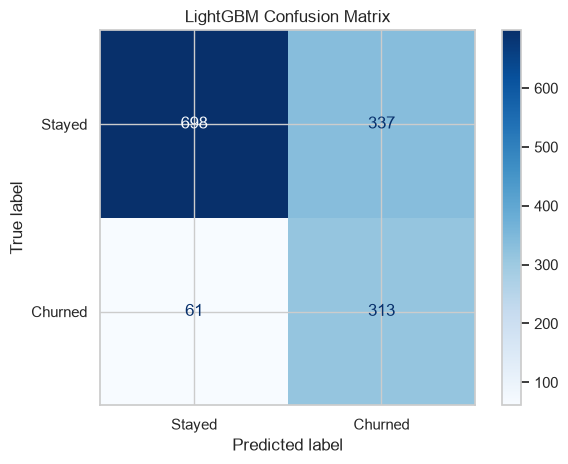

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lightgbm_predictions,
    labels=[0, 1],
    display_labels=[
        "Stayed",
        "Churned"
    ],
    cmap="Blues",
    values_format="d"
)

plt.title("LightGBM Confusion Matrix")
plt.tight_layout()
plt.show()

### LightGBM interpretation and model comparison

LightGBM retains its expanded regularized search space, but candidate selection now uses constrained recall so it is evaluated under the same outreach limit as every other model. The final table shows whether its nonlinear ranking produces higher churn recall without exceeding the acceptable false-positive burden.

## Support-vector-machine classifier

A support vector machine (SVM) is evaluated with both linear and radial-basis-function (RBF) boundaries. The same split, fold-safe preprocessing, cross-validation folds, and constrained-recall objective are retained.

### Modeling pipeline

SVMs are sensitive to feature scale. The search therefore compares the existing minimum–maximum scaling with standardization while fitting both transformations inside every cross-validation fold.

In [44]:
from sklearn.svm import SVC

svm_standard_preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "numeric",
        StandardScaler(),
        numeric_features
    )
])

svm_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        SVC(cache_size=500)
    )
])

### Hyperparameter search space

The expanded search tunes the SVM boundary and preprocessing:

- `C` controls the penalty for classification errors. A larger value tries harder to classify the training examples correctly but may overfit.
- `gamma` controls how far each training example influences the RBF boundary; it is omitted for the linear kernel.
- `class_weight` increases the cost of missing churners.
- `preprocess` compares minimum–maximum scaling with standardization.

Separate parameter dictionaries prevent irrelevant `gamma` values from being tested with the linear kernel. Randomized search evaluates 80 combinations under the common 31% validation false-positive-rate cap.

In [45]:
svm_class_weights = [
    None,
    "balanced",
    {0: 1, 1: 1.5},
    {0: 1, 1: 2.0},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3.0},
    {0: 1, 1: 3.5},
    {0: 1, 1: 4.0}
]

svm_parameter_distributions = [
    {
        "preprocess": [preprocessor, svm_standard_preprocessor],
        "model__kernel": ["linear"],
        "model__C": [0.003, 0.01, 0.03, 0.1, 0.3, 1],
        "model__class_weight": svm_class_weights
    },
    {
        "preprocess": [preprocessor, svm_standard_preprocessor],
        "model__kernel": ["rbf"],
        "model__C": [0.003, 0.01, 0.03, 0.1, 0.3, 1],
        "model__gamma": [
            0.0001,
            0.0003,
            0.001,
            0.003,
            0.01,
            0.03,
            "scale"
        ],
        "model__class_weight": svm_class_weights
    }
]

### Model selection

Randomized search evaluates 80 reproducible SVM combinations with five-fold stratified cross-validation and selects the combination with the highest recall under the 31% false-positive-rate cap.

In [46]:
svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_parameter_distributions,
    n_iter=80,
    scoring=recall_at_fpr_cap,
    cv=cross_validation,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

svm_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...e_size=500))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model__C': [0.003, 0.01, ...], 'model__class_weight': [None, 'balanced', ...], 'model__kernel': ['linear'], 'preprocess': [ColumnTransfo...alCharges'])]), ColumnTransfo...alCharges'])])]}, {'model__C': [0.003, 0.01, ...], 'model__class_weight': [None, 'balanced', ...], 'model__gamma': [0.0001, 0.0003, ...], 'model__kernel': ['rbf'], ...}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",<function rec...0024F7FF91590>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluat

### Test performance

The best cross-validated SVM is evaluated once on the untouched test set. Its F2-score and classification report use the same format as every previous model.

In [47]:
svm_model = svm_search.best_estimator_

svm_predictions = svm_model.predict(
    X_test
)

print("Best SVM parameters:")
print(svm_search.best_params_)

print("\nBest cross-validation recall at the FPR cap:")
print(round(svm_search.best_score_, 3))

print("\nTest F2-score:")
print(round(fbeta_score(y_test, svm_predictions, beta=2), 3))

print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=[
            "Stayed",
            "Churned"
        ],
        digits=3
    )
)

Best SVM parameters:
{'preprocess': ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod']),
                                ('numeric', MinMaxScaler(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges'])]), 'model__kernel': 'linear', 'model__class_weight': {0: 1, 1: 1.5}, 'model__C': 1}

Best cross-validation recall at the FPR cap:
0.833

Test F2-score:
0.629
              precision    recall  f1-score   supp

### Confusion matrix

The confusion matrix presents the SVM's correct and incorrect predictions as customer counts.

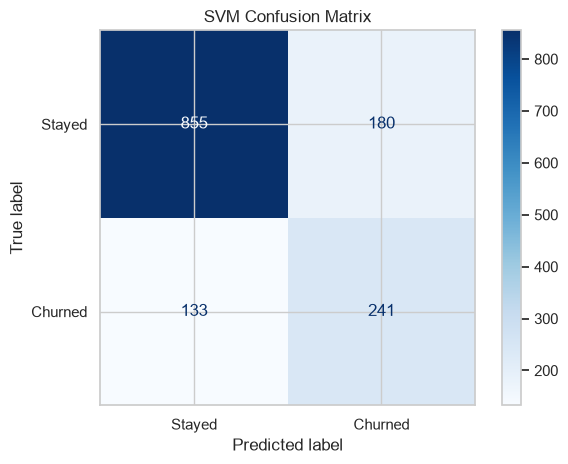

In [48]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_predictions,
    labels=[0, 1],
    display_labels=[
        "Stayed",
        "Churned"
    ],
    cmap="Blues",
    values_format="d"
)

plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

### SVM interpretation and model comparison

The SVM search now explores the lower `C` and `gamma` ranges indicated by the previous boundary winner, compares linear and RBF kernels, and tests two scaling methods. Its constrained result should be judged by whether the wider search improves recall at the same FPR—not by whether a lower decision threshold simply creates more positive predictions.

## Constrained decision-threshold selection

Each selected classifier initially converts its score or probability into a class using a default threshold. Instead of lowering that threshold until F2 is largest, the notebook now uses out-of-fold training scores to find the threshold with the highest churn recall while keeping the false-positive rate at or below 31%. The test labels do not participate in threshold selection.

### Select one constrained threshold for every model

`cross_val_predict` generates a score for every training customer from a model that did not train on that customer. The ROC curve then supplies candidate thresholds. Among thresholds that satisfy the training FPR cap, the code selects the one with the highest recall; ties favor the lower false-positive rate. The selected estimator is already refitted on all training data by its search object, so its frozen threshold can be evaluated on the test set.

In [49]:
selected_models = {
    "Logistic Regression": logistic_search.best_estimator_,
    "Decision Tree": tree_search.best_estimator_,
    "Random Forest": forest_search.best_estimator_,
    "LightGBM": lightgbm_search.best_estimator_,
    "SVM": svm_search.best_estimator_
}

default_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": tree_predictions,
    "Random Forest": forest_predictions,
    "LightGBM": lightgbm_predictions,
    "SVM": svm_predictions
}

selected_thresholds = {}
threshold_tuned_predictions = {}
threshold_results_rows = []

for model_name, selected_model in selected_models.items():
    prediction_method = (
        "predict_proba"
        if hasattr(selected_model, "predict_proba")
        else "decision_function"
    )

    out_of_fold_scores = cross_val_predict(
        selected_model,
        X_train,
        y_train,
        cv=cross_validation,
        method=prediction_method,
        n_jobs=-1
    )

    if prediction_method == "predict_proba":
        out_of_fold_scores = out_of_fold_scores[:, 1]

    training_fprs, training_recalls, candidate_thresholds = roc_curve(
        y_train,
        out_of_fold_scores
    )

    allowed_positions = np.flatnonzero(
        training_fprs <= MAX_FALSE_POSITIVE_RATE
    )
    best_position = allowed_positions[
        np.argmax(training_recalls[allowed_positions])
    ]
    selected_threshold = candidate_thresholds[best_position]

    test_scores = positive_class_scores(selected_model, X_test)
    tuned_predictions = (test_scores >= selected_threshold).astype(int)

    default_tn, default_fp, default_fn, default_tp = confusion_matrix(
        y_test,
        default_predictions[model_name],
        labels=[0, 1]
    ).ravel()
    tuned_tn, tuned_fp, tuned_fn, tuned_tp = confusion_matrix(
        y_test,
        tuned_predictions,
        labels=[0, 1]
    ).ravel()

    default_test_f2 = fbeta_score(
        y_test,
        default_predictions[model_name],
        beta=2
    )
    tuned_test_f2 = fbeta_score(
        y_test,
        tuned_predictions,
        beta=2
    )

    selected_thresholds[model_name] = selected_threshold
    threshold_tuned_predictions[model_name] = tuned_predictions
    threshold_results_rows.append({
        "Model": model_name,
        "Selected threshold": selected_threshold,
        "Training OOF recall": training_recalls[best_position],
        "Training OOF FPR": training_fprs[best_position],
        "Default test F2": default_test_f2,
        "Constrained test F2": tuned_test_f2,
        "Default test recall": default_tp / (default_tp + default_fn),
        "Constrained test recall": recall_score(y_test, tuned_predictions),
        "Default test precision": default_tp / (default_tp + default_fp),
        "Constrained test precision": precision_score(
            y_test, tuned_predictions, zero_division=0
        ),
        "Default test FPR": default_fp / (default_fp + default_tn),
        "Constrained test FPR": tuned_fp / (tuned_fp + tuned_tn),
        "False positives": tuned_fp,
        "False negatives": tuned_fn,
        "Customers flagged": tuned_tp + tuned_fp,
        "Contact rate": (tuned_tp + tuned_fp) / len(y_test)
    })

threshold_results = pd.DataFrame(
    threshold_results_rows
).set_index("Model")

display(threshold_results.round(3))

,Selected threshold,Training OOF recall,Training OOF FPR,Default test F2,Constrained test F2,Default test recall,Constrained test recall,Default test precision,Constrained test precision,Default test FPR,Constrained test FPR,False positives,False negatives,Customers flagged,Contact rate
Model,,,,,,,,,,,,,,,
Logistic Regression,0.423,0.829,0.310,0.692,0.715,0.757,0.816,0.516,0.479,0.256,0.321,332,69,637,0.452
Decision Tree,0.412,0.823,0.310,0.698,0.719,0.759,0.824,0.529,0.476,0.244,0.328,339,66,647,0.459
Random Forest,0.527,0.846,0.307,0.730,0.737,0.842,0.840,0.477,0.494,0.334,0.310,321,60,635,0.451
LightGBM,0.495,0.846,0.310,0.729,0.731,0.837,0.840,0.482,0.482,0.326,0.327,338,60,652,0.463
SVM,-0.720,0.830,0.310,0.629,0.716,0.644,0.813,0.572,0.485,0.174,0.312,323,70,627,0.445


### Constrained-threshold interpretation

The results table now exposes the complete operational trade-off instead of reporting F2 alone. `Training OOF FPR` is guaranteed to respect the selected cap because it is used to choose the threshold. `Constrained test FPR` may be slightly above or below 31% because the test set is a separate sample; this is an honest generalization check, not a reason to retune on the test set.

The SVM threshold can be negative because `SVC` uses a decision-function score rather than a probability. Its value should not be compared directly with the probability thresholds of the other models.

## Next steps

- Replace the provisional 31% FPR cap with the retention team's actual monthly false-positive or contact-capacity limit.
- Select the final model using training cross-validation stability and the constrained test metrics together, not F2 alone.
- Calibrate predicted probabilities only if the business needs reliable churn probabilities rather than ranked risk scores.

## Final model comparison

The first Seaborn bar chart compares test F2 before and after constrained threshold selection. The second compares each constrained model's churn recall, precision, and false-positive rate. A useful model should raise recall while keeping its FPR near the agreed cap rather than winning only on F2.

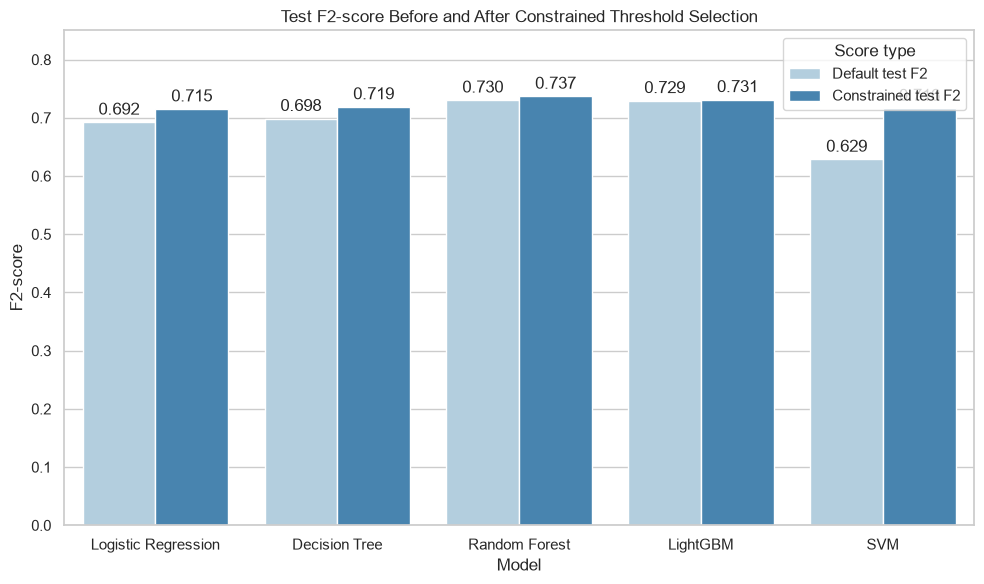

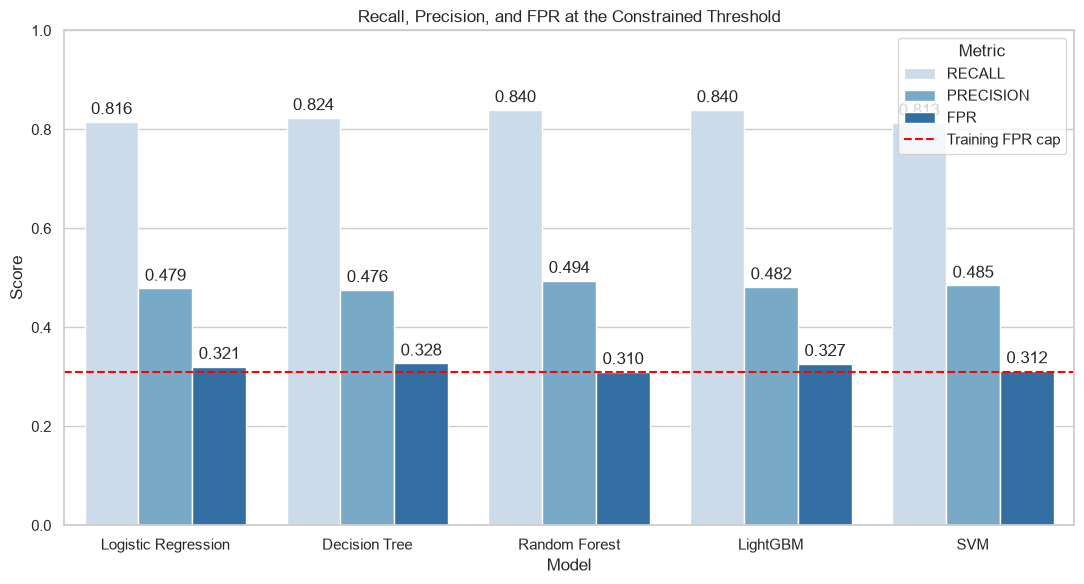

In [50]:
comparison_scores = (
    threshold_results
    .reset_index()
    .melt(
        id_vars="Model",
        value_vars=[
            "Default test F2",
            "Constrained test F2"
        ],
        var_name="Score type",
        value_name="F2-score"
    )
)

plt.figure(figsize=(10, 6))
comparison_chart = sns.barplot(
    data=comparison_scores,
    x="Model",
    y="F2-score",
    hue="Score type",
    order=list(selected_models),
    palette="Blues"
)

for bars in comparison_chart.containers:
    comparison_chart.bar_label(bars, fmt="%.3f", padding=3)

comparison_chart.set(
    title="Test F2-score Before and After Constrained Threshold Selection",
    xlabel="Model",
    ylabel="F2-score",
    ylim=(0, 0.85)
)
comparison_chart.legend(title="Score type")
plt.tight_layout()
plt.show()

operating_metrics = (
    threshold_results[[
        "Constrained test recall",
        "Constrained test precision",
        "Constrained test FPR"
    ]]
    .reset_index()
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

operating_metrics["Metric"] = (
    operating_metrics["Metric"]
    .str.replace("Constrained test ", "", regex=False)
    .str.upper()
)

plt.figure(figsize=(11, 6))
operating_chart = sns.barplot(
    data=operating_metrics,
    x="Model",
    y="Score",
    hue="Metric",
    order=list(selected_models),
    palette="Blues"
)

for bars in operating_chart.containers:
    operating_chart.bar_label(bars, fmt="%.3f", padding=3)

operating_chart.axhline(
    MAX_FALSE_POSITIVE_RATE,
    color="red",
    linestyle="--",
    label="Training FPR cap"
)
operating_chart.set(
    title="Recall, Precision, and FPR at the Constrained Threshold",
    xlabel="Model",
    ylabel="Score",
    ylim=(0, 1)
)
operating_chart.legend(title="Metric")
plt.tight_layout()
plt.show()

## Final model: Random Forest

Random Forest is selected as the final model because it tied LightGBM for the highest constrained cross-validation recall (84.9%) while flagging a slightly smaller share of test customers in the validated run. It therefore provides the strongest current balance between detecting churners and limiting unnecessary retention contacts.

### Final configuration

- **Model type:** an ensemble of 400 decision trees. Each tree learns different customer segments, and their probability estimates are averaged.
- **Selected tree structure:** maximum depth 8, at least 5 customers per leaf, and at least 20 customers required to split a node. These controls reduce overly specific rules.
- **Feature sampling:** `sqrt`, so every split considers a random subset of the encoded features. This creates diversity between trees.
- **Customer sampling:** full-size bootstrap samples (`max_samples=None`). Each tree receives a different sample because bootstrap sampling uses replacement.
- **Split criterion:** Gini impurity.
- **Class weight:** churners receive four times the error weight of retained customers. This changes the learned forest, while the separate threshold controls the final outreach decision.
- **Preprocessing:** categorical columns are one-hot encoded with unknown categories ignored; `tenure`, `MonthlyCharges`, and `TotalCharges` are scaled. The fitted preprocessing and model are exported together.
- **Decision threshold:** learned from out-of-fold training probabilities to maximize churn recall while keeping training FPR at or below 31%. It is exported with the model rather than assuming the usual 0.5 threshold.

### Important interpretation

The model returns a churn score for each customer. A customer is sent to retention when that score is at least the exported threshold. The score helps rank risk, but it should not automatically be interpreted as a perfectly calibrated real-world probability. The 31% FPR cap is provisional and should be replaced with the company's actual outreach-cost or campaign-capacity limit before production deployment.

In [51]:
from pathlib import Path

import joblib
import sklearn

final_model = selected_models["Random Forest"]
final_threshold = float(selected_thresholds["Random Forest"])
final_test_metrics = threshold_results.loc["Random Forest"].to_dict()

model_directory = project_root / "models"
model_directory.mkdir(exist_ok=True)
model_path = model_directory / "random_forest_churn_bundle.joblib"

random_forest_bundle = {
    "bundle_version": 1,
    "pipeline": final_model,
    "threshold": final_threshold,
    "positive_class": 1,
    "target_mapping": {"No": 0, "Yes": 1},
    "feature_columns": X_train.columns.tolist(),
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "selected_parameters": forest_search.best_params_,
    "training_fpr_cap": MAX_FALSE_POSITIVE_RATE,
    "test_metrics": final_test_metrics,
    "sklearn_version": sklearn.__version__,
    "input_notes": {
        "customerID": "Exclude this identifier before prediction.",
        "SeniorCitizen": "Use the strings Yes or No.",
        "TotalCharges": "Use a numeric value; zero is valid for a zero-tenure customer."
    }
}

joblib.dump(random_forest_bundle, model_path, compress=3)

# Small export check: the saved model must reproduce the fitted model's scores.
reloaded_bundle = joblib.load(model_path)
original_scores = final_model.predict_proba(X_test.head())[:, 1]
reloaded_scores = reloaded_bundle["pipeline"].predict_proba(
    X_test.head()
)[:, 1]
assert np.allclose(original_scores, reloaded_scores)
assert reloaded_bundle["threshold"] == final_threshold

print(f"Exported final model to: {model_path.resolve()}")
print(f"Decision threshold: {final_threshold:.3f}")
print(f"Artifact size: {model_path.stat().st_size / 1_000_000:.2f} MB")

Exported final model to: D:\E& AI Internship\telecome-churn-ml\models\random_forest_churn_bundle.joblib
Decision threshold: 0.527
Artifact size: 2.29 MB


### Using the exported model in an application

The exported file is a dictionary containing the complete fitted pipeline, the selected threshold, the input-column contract, parameters, library version, and evaluation metadata. The accompanying `app/inference.py` module applies the same basic cleaning rules and returns both the churn score and the final retention decision.

```python
from app import load_model_bundle, predict_churn

bundle = load_model_bundle()
predictions = predict_churn(new_customers, bundle)
print(predictions)
```

`new_customers` can be one customer dictionary or a pandas DataFrame. Only load a `joblib` artifact that you trust, because pickle-based model formats can execute code while loading. The application environment should use the same scikit-learn version stored in the bundle.